# 기본 통계량 및 분포 분석

In [329]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [330]:
df_cleaned = pd.read_csv(r'C:\Users\컴퓨터\Documents\data-analysis-project-BBB\data\first_clean_data.csv')
df = pd.read_csv(r'C:\Users\컴퓨터\Documents\data-analysis-project-BBB\data\2025_Airbnb_NYC_listings.csv')

In [331]:
# 1. 25~50번째 컬럼 슬라이싱 + review_scores_rating 포함
target_columns = list(df_cleaned.columns) 
if 'review_scores_rating' not in target_columns:
    target_columns.append('review_scores_rating')

# 2. 그 중 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 3. 스피어만 상관계수 계산 (이상치에 강함)
review_scores_rating_corr = numeric_df.corr(method='spearman')['review_scores_rating'].sort_values(ascending=False)

print("--- 평점과 상관관계가 높은 주요 변수 ---")
print(review_scores_rating_corr)

--- 평점과 상관관계가 높은 주요 변수 ---
review_scores_rating                            1.000000
review_scores_accuracy                          0.778852
review_scores_value                             0.711800
review_scores_cleanliness                       0.707056
review_scores_communication                     0.691476
review_scores_checkin                           0.647184
review_scores_location                          0.473748
id                                              0.129799
Unnamed: 0                                      0.129747
log_price                                       0.100145
price                                           0.100145
host_response_rate                              0.069837
bedrooms                                        0.059570
estimated_revenue_l365d                         0.041775
estimated_occupancy_l365d                       0.010973
longitude                                       0.008880
host_response_time                              0.001071
calc

# 평점 4.8점 이상, 이하로 나눠서 두 집단 비교

In [332]:
# test_df1을 새로 만들고 거기에 평균 4.8이상/미만 파생컬럼 생성

# 결측치 제거(평점이 null일때 무언가로 채우면 안될거같아서 과감히 빼버리기로 함)
test_df1 = df_cleaned.dropna(subset=['review_scores_rating']).copy()

# 파생 컬럼 생성
test_df1['rating_group'] = 'Low'
test_df1.loc[test_df1['review_scores_rating'] >= 4.8, 'rating_group'] = 'High'
print(test_df1['rating_group'].value_counts())

rating_group
High    9122
Low     6364
Name: count, dtype: int64


## 1. 두 집단별 방 유형 상관정도 구하기(카이제곱 검정과 크래머 V 계수 구하기)

In [333]:
test_df1['room_type'].value_counts()

room_type
Entire home/apt    8852
Private room       6463
Hotel room          114
Shared room          57
Name: count, dtype: int64

### 1-1. Hotel room, Shared room 포함 버전

In [334]:
ct_room = pd.crosstab(test_df1['room_type'],test_df1['rating_group'])
result = chi2_contingency(ct_room)
result

Chi2ContingencyResult(statistic=np.float64(34.39724235899625), pvalue=np.float64(1.6332471573893443e-07), dof=3, expected_freq=array([[5214.25442335, 3637.74557665],
       [  67.15149167,   46.84850833],
       [3807.01833915, 2655.98166085],
       [  33.57574583,   23.42425417]]))

In [335]:
ct_room

rating_group,High,Low
room_type,,
Entire home/apt,5353,3499
Hotel room,48,66
Private room,3682,2781
Shared room,39,18


In [336]:
# Cramer's V
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

cramers_v(ct_room)

np.float64(0.047129429832478476)

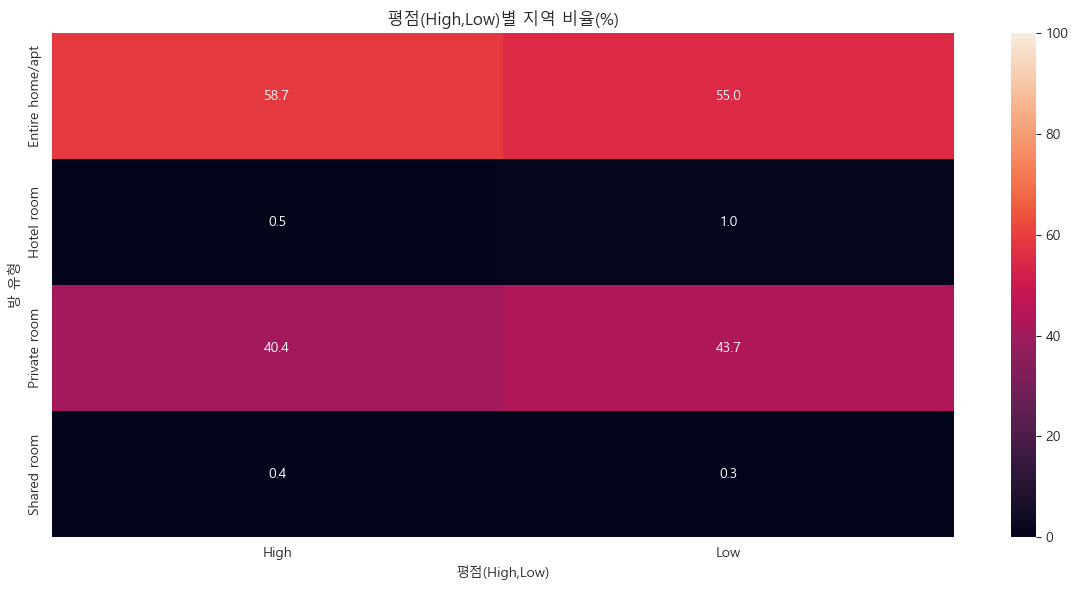

In [337]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_room_percent = ct_room.div(ct_room.sum(axis=0), axis=1) * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_room_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("방 유형")
plt.tight_layout()
plt.show()

### 1-2. Hotel room 제거 버전

In [338]:
ct = pd.crosstab(test_df1['room_type'], test_df1['rating_group'])
ct_2 = ct.loc[~ct.index.isin(['Hotel room','Shared room'])]
ct_2

rating_group,High,Low
room_type,,
Entire home/apt,5353,3499
Private room,3682,2781


In [339]:
result = chi2_contingency(ct_2)
result

Chi2ContingencyResult(statistic=np.float64(18.791081253940018), pvalue=np.float64(1.4584756065132334e-05), dof=1, expected_freq=array([[5222.18870389, 3629.81129611],
       [3812.81129611, 2650.18870389]]))

In [340]:
# Cramer's V
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v


cramers_ct_2 = cramers_v(ct_2)
print(f'크래머 V 계수: {cramers_ct_2}')

크래머 V 계수: 0.035028164829252154


### 1-3. 시각화 (Hotel room 제외)

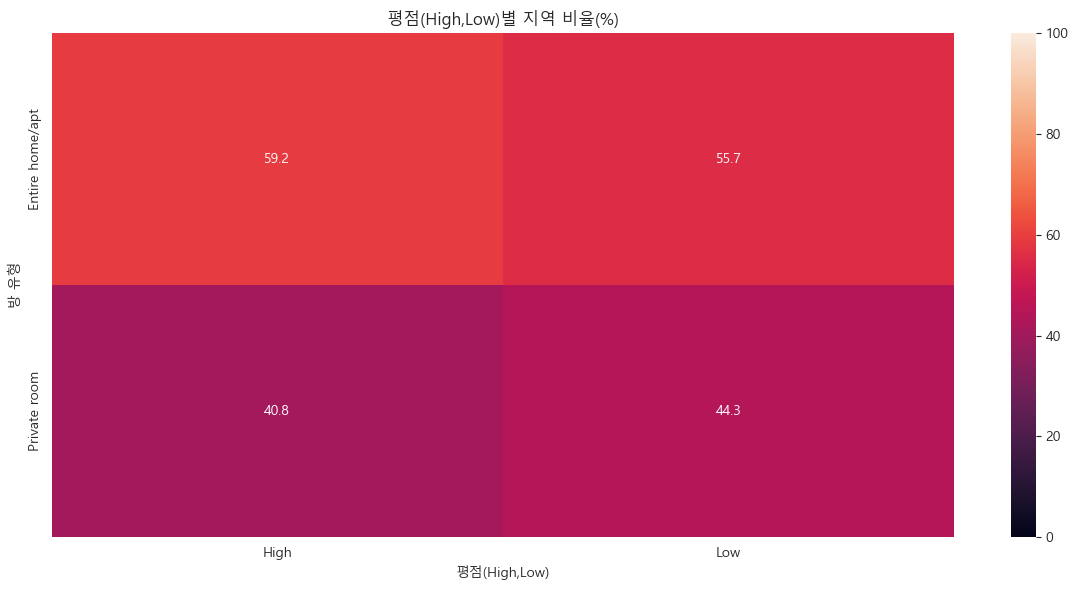

In [341]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_2_percent = ct_2.div(ct_2.sum(axis=0), axis=1) * 100

# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_2_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("방 유형")
plt.tight_layout()
plt.show()

## 2. 두 집단별 지역 상관정도 구하기(카이제곱 검정과 크래머 V 계수 구하기)

In [342]:
ct_neighbourhood = pd.crosstab(test_df1['neighbourhood_group_cleansed'],test_df1['rating_group'])
result = chi2_contingency(ct_neighbourhood)
result

Chi2ContingencyResult(statistic=np.float64(202.40815038791274), pvalue=np.float64(1.1405039925805603e-42), dof=4, expected_freq=array([[ 414.68991347,  289.31008653],
       [3300.43691076, 2302.56308924],
       [3667.41392225, 2558.58607775],
       [1591.01911404, 1109.98088596],
       [ 148.44013948,  103.55986052]]))

In [343]:
ct_neighbourhood

rating_group,High,Low
neighbourhood_group_cleansed,,
Bronx,397,307
Brooklyn,3665,1938
Manhattan,3285,2941
Queens,1609,1092
Staten Island,166,86


In [344]:
# Cramer's V
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v


cramers = cramers_v(ct_neighbourhood)
print(f'크래머 V 계수: {cramers}')

크래머 V 계수: 0.1143258320173284


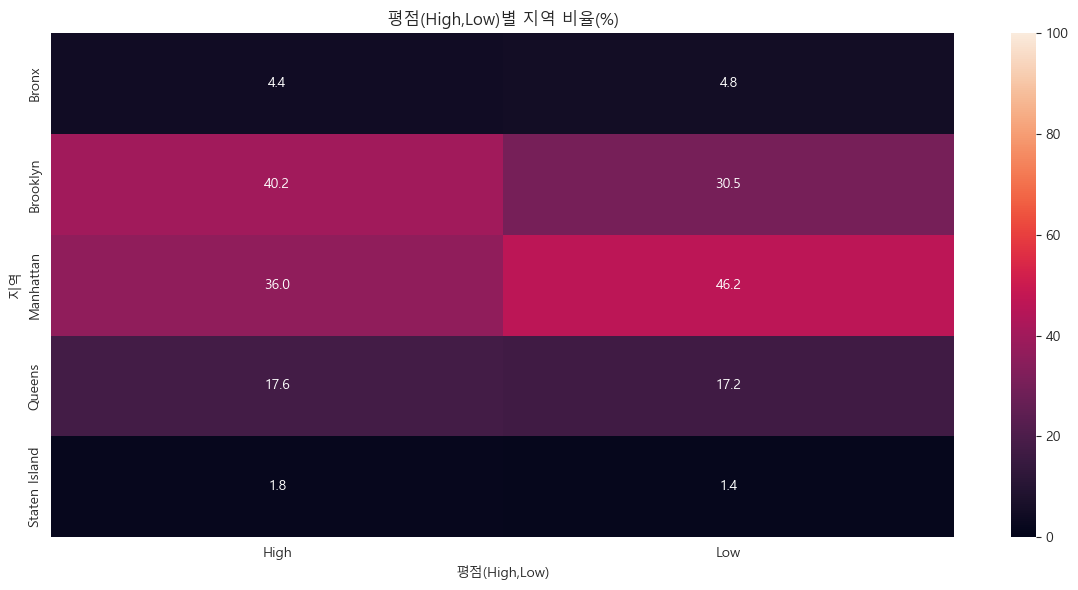

In [345]:
# 1) 교차표 만들기 + 2) 비율로 바꾸기(행 기준) -> 퍼센트로 보기 좋게 * 100
ct_neighbourhood_percent = ct_neighbourhood.div(ct_neighbourhood.sum(axis=0), axis=1) * 100
# 3) heatmap으로 색칠하기
# annot=True: 각 칸에 숫자를 같이 표시
# fmt=".1f": 숫자를 소수 1자리로 표시
# vmin=0, vmax=100: 퍼센트 범위를 고정해서 색이 과장되지 않게 함
sns.heatmap(ct_neighbourhood_percent, annot=True, fmt=".1f", vmin=0, vmax=100)
plt.title("평점(High,Low)별 지역 비율(%)")
plt.xlabel("평점(High,Low)")
plt.ylabel("지역")
plt.tight_layout()
plt.show()

## 3. 두 집단 별 기준으로 각 집단의 숙소들은 무슨 AMENITIES를 쓰는지 TOP 10 추출

### 3-1. TOP 10 amenities 출력

In [346]:
import ast
from collections import Counter

# 1. 문자열(String) 형태를 진짜 리스트(List)로 변환
# 데이터가 "['Wifi', 'Heating']" 처럼 따옴표까지 포함된 글자라면 이 과정이 꼭 필요!!
test_df1['amenities'] = test_df1['amenities'].apply(ast.literal_eval)

# 2. 리스트를 개별 행으로 펼치기 (Explode)
# 한 칸에 들어있던 [A, B, C]를 각각 3개의 행(A / B / C)으로 쪼개줍니다.
exploded_amenities = test_df1['amenities'].explode()

# 3. 개수 세고 상위 10개 추출
top_10_amenities = exploded_amenities.value_counts().head(10)

### 3-2. 평점 별로 TOP 10 amenities 출력

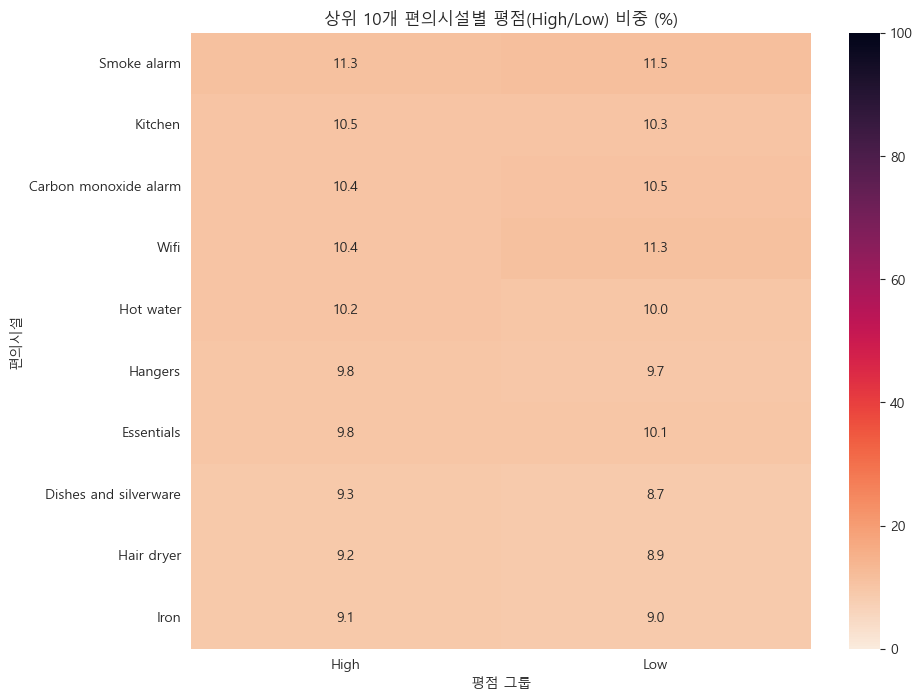

In [347]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 'amenities' 리스트 펼치기 (rating_group 컬럼 유지)
# test_df1이 아닌 exploded_df를 새로 정의하여 인덱스 일관성을 유지합니다.
exploded_df = test_df1.explode('amenities')

# 2. 상위 10개 편의시설 리스트 추출
top_10_list = exploded_df['amenities'].value_counts().head(10).index

# 3. 상위 10개 시설에 해당하는 데이터만 필터링
df_top10 = exploded_df[exploded_df['amenities'].isin(top_10_list)]

# 4. crosstab 대신 groupby를 사용하여 비율 계산 (에러 방지)
# 편의시설별로 rating_group(High/Low)의 빈도수를 구한 뒤 비율로 변환합니다.
ct_amenity = df_top10.groupby(['amenities', 'rating_group']).size().unstack(fill_value=0)
ct_amenity_percent = ct_amenity.div(ct_amenity.sum(axis=0), axis=1) * 100

# 5. Seaborn 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(ct_amenity_percent.sort_values(by='High', ascending=False), 
            annot=True, 
            fmt=".1f", 
            cmap="rocket_r", 
            vmin=0, vmax=100)

plt.title('상위 10개 편의시설별 평점(High/Low) 비중 (%)')
plt.xlabel('평점 그룹')
plt.ylabel('편의시설')
plt.show()

In [348]:
from scipy.stats import chi2_contingency

# 1. 비율이 아닌 '실제 빈도수'가 담긴 ct_amenity를 사용합니다.
# (ct_amenity_percent를 구하기 전 단계의 데이터프레임)
chi2, p, dof, expected = chi2_contingency(ct_amenity)

print(f"카이제곱 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")

# 결과 해석
if p < 0.05:
    print("결과: 통계적으로 유의미한 차이가 있습니다. (편의시설에 따라 평점 분포가 다름)")
else:
    print("결과: 통계적으로 유의미한 차이가 없습니다.")

카이제곱 통계량: 50.7279
p-value: 0.0000
결과: 통계적으로 유의미한 차이가 있습니다. (편의시설에 따라 평점 분포가 다름)


------------------------------
------------------------------
------------------------------
------------------------------

# 다른 분들 코드 훔치기!

In [349]:
df_cleaned['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

Entire Home 데이터 개수: 12635
Private Room 데이터 개수: 9178


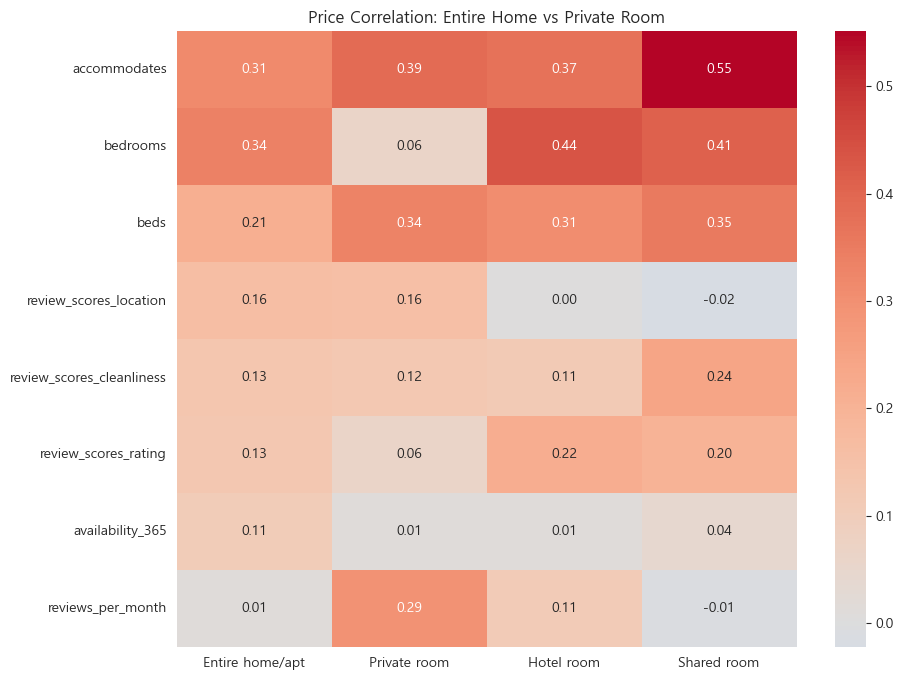

In [350]:
target_cols = [
    'price', 'accommodates', 'bedrooms', 'beds', 
    'review_scores_location', 'review_scores_cleanliness', 
    'review_scores_rating', 'availability_365', 'reviews_per_month'
]

private_df = df_cleaned[df_cleaned['room_type'] == 'Private room'][target_cols]
entire_df = df_cleaned[df_cleaned['room_type'] == 'Entire home/apt'][target_cols]
Hotel_df = df_cleaned[df_cleaned['room_type'] == 'Hotel room'][target_cols]
Shared_df = df_cleaned[df_cleaned['room_type'] == 'Shared room'][target_cols]

# 데이터 개수 확인 (신뢰도 체크)
print(f"Entire Home 데이터 개수: {len(entire_df)}")
print(f"Private Room 데이터 개수: {len(private_df)}")

# 3. 그룹별 스피어만 상관계수 계산
private_corr = private_df.corr(method='spearman')['price'].rename('Private room')
entire_corr = entire_df.corr(method='spearman')['price'].rename('Entire home/apt')
Hotel_df = Hotel_df.corr(method='spearman')['price'].rename('Hotel room')
Shared_df = Shared_df.corr(method='spearman')['price'].rename('Shared room')

# 4. 결과 합치기
comparison_df = pd.concat([entire_corr, private_corr, Hotel_df, Shared_df], axis=1).drop('price') # 'price' 자기 자신은 제외

# 5. 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(comparison_df, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Price Correlation: Entire Home vs Private Room')
plt.show()

In [351]:
# price "$", "," 제거 -> float형태로 변경
df['price'] = (df['price'].str.replace("$", "").str.replace(",","").astype(float))
df['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
22303     72.0
22304     58.0
22305    299.0
22306    200.0
22307     58.0
Name: price, Length: 22308, dtype: float64

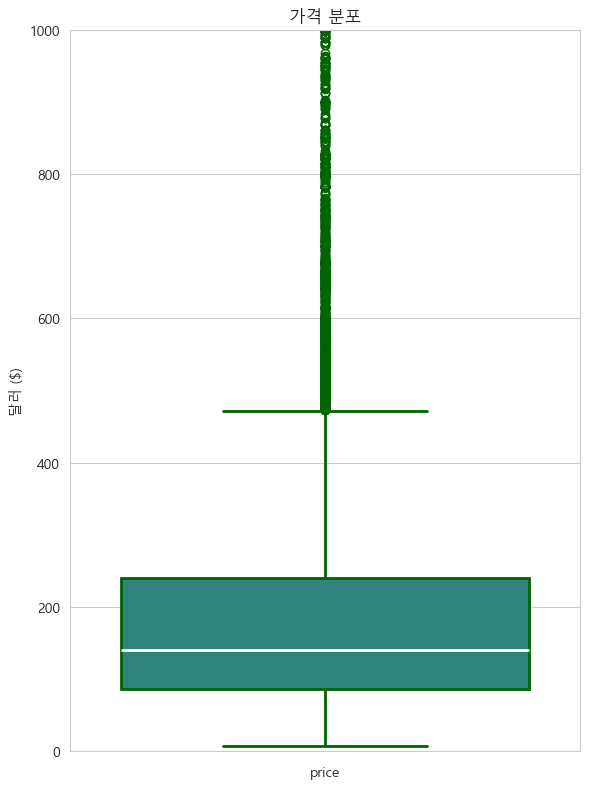

In [352]:
data_price = df[['price']]
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, y='price', palette='viridis', linecolor='darkgreen', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
plt.title("가격 분포")
plt.xlabel("price")
plt.ylabel("달러 ($)")
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

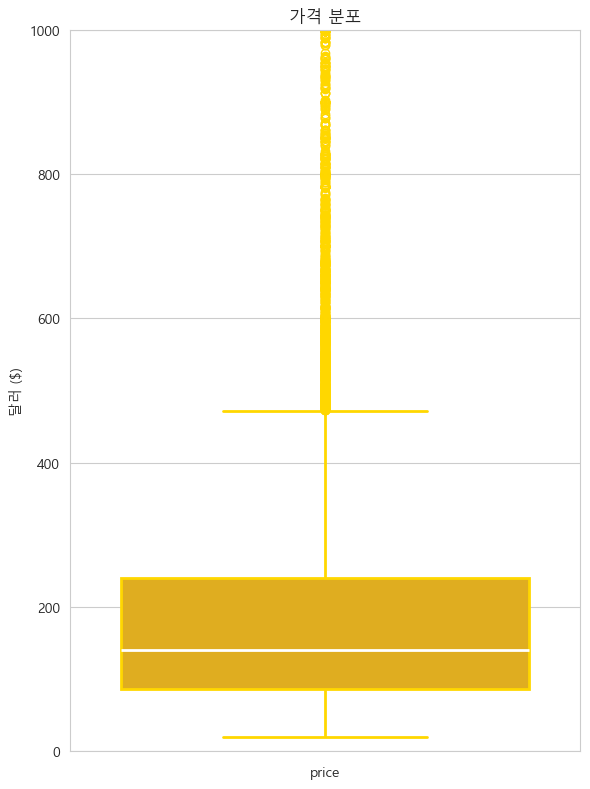

In [353]:
data_price = df_cleaned[['price']]
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, y='price', palette='Wistia', linecolor='gold', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
plt.title("가격 분포")
plt.xlabel("price")
plt.ylabel("달러 ($)")
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

In [354]:
df[['price']].describe()

,price
count,22308.000000
mean,213.835216
std,427.599435
min,7.000000
25%,85.000000
50%,140.000000
75%,240.000000
max,20000.000000


In [355]:
df_cleaned[['price']].describe()

,price
count,22248.000000
mean,214.138574
std,428.107042
min,19.000000
25%,85.000000
50%,140.000000
75%,240.000000
max,20000.000000


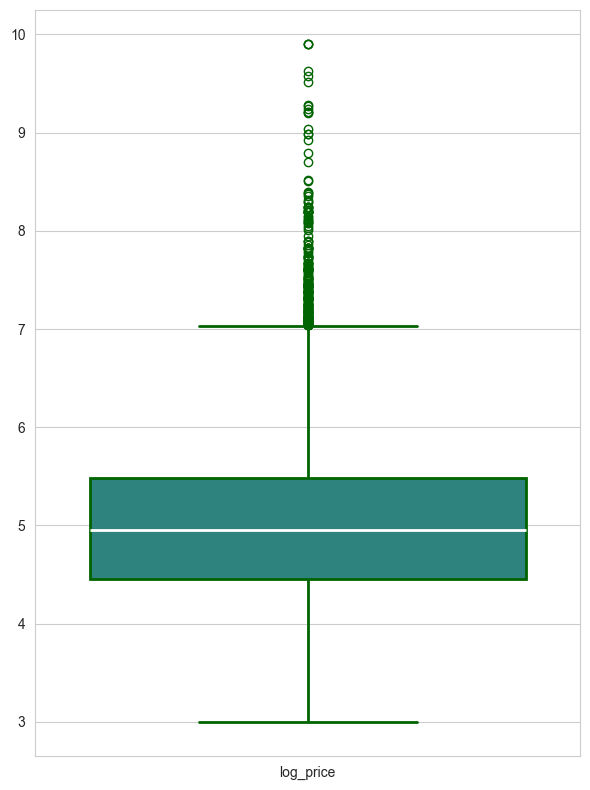

In [356]:
data_price = df_cleaned[['log_price']]
plt.figure(figsize=(6, 8))
sns.boxplot(data=data_price, palette='viridis', linecolor='darkgreen', linewidth=2, medianprops={'color': 'white'})
sns.set_style("whitegrid")
# plt.title("가격 분포")
# plt.xlabel("price")
# plt.ylabel("달러 ($)")
plt.tight_layout()
plt.show()

## 가격 관련 상관계수 구하기

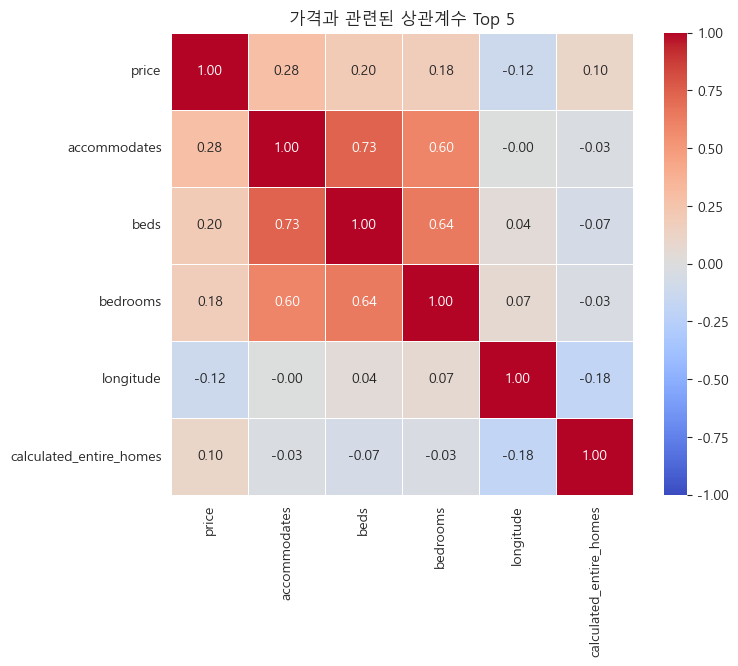

In [358]:
# 가격 기준 상관계수 구할 컬럼 선정
target_columns = list(df_cleaned.columns)

# 수치형 데이터만 추출
numeric_df = df_cleaned[target_columns].select_dtypes(include=['number'])

# 💡 핵심 추가: 상관계수를 구하기 전에 'log_price' 컬럼을 데이터프레임에서 제외합니다.
# (에러 방지를 위해 errors='ignore'를 추가하면 혹시 컬럼이 없어도 코드가 멈추지 않습니다.)
numeric_df = numeric_df.drop(columns=['log_price'], errors='ignore')
numeric_df.rename(columns={'calculated_host_listings_count_entire_homes': 'calculated_entire_homes'}, inplace=True)

# 수치형 데이터에서 상관계수 행렬 구하기
numeric_corr_matrix = numeric_df.corr()

# 'price'와 상관계수가 높은 상위 5개 변수 추출 (price 자기 자신을 포함하여 6개 선택)  /  절대값 추가를 위해 .abs() 추가
top_cols = numeric_corr_matrix.abs().nlargest(6, 'price').index

# 추출한 컬럼들로만 구성된 새로운 상관계수 데이터프레임 만들기
top_corr = numeric_df[top_cols].corr()

# 글씨 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

# 히트맵 그리기
plt.figure(figsize=(8, 6)) # 그래프 크기 조절
sns.heatmap(top_corr, 
            annot=True,        # 셀 안에 상관계수 숫자 표시
            fmt='.2f',         # 숫자를 소수점 둘째 자리까지만 표시
            cmap='coolwarm',   # 색상 테마 (추천: coolwarm, RdYlBu_r, Blues)
            vmin=-1, vmax=1,   # 상관계수 최소/최대 범위 고정 (-1 ~ 1)
            linewidths=.5,     # 셀 사이 구분선 굵기
            square=True)       # 각 셀을 정사각형 모양으로 만들기

# 그래프 제목 설정
plt.title('가격과 관련된 상관계수 Top 5')
plt.show()